In [3]:
import numpy as np
import torch
import os
import sys
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import pandas as pd
from sklearn.utils import resample

helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
CUDA = torch.cuda.is_available()
CUDA = False
device = torch.device("cuda" if CUDA else "cpu")
print("Device:", device)

dataset_path = "/home/aegis/Titan1/NRAD/data/Scaled_Regions"
dataset_path_weight = "/home/aegis/Titan1/NRAD/data/Scaled_Regions_with_weights"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
model_path = "/home/aegis/Titan1/NRAD/data/Models"
eval_dir = f"CWoLa_CR"

with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

Device: cpu


In [5]:
print("Loadding Test events...")
mc_events_cr = pd.read_parquet(os.path.join(dataset_path, "MC_CR_test.parquet"))
mc_events_cr_weight = pd.read_parquet(os.path.join(dataset_path_weight, "MC_CR_test.parquet"))
data_events_cr = pd.read_parquet(os.path.join(dataset_path, "Data_CR_test.parquet"))

context_var = ['ht', 'met_recalc_pt']
features = [col for col in mc_events_cr.columns if col not in context_var]

print("Context Variables:", context_var)
print("Feature Variables:", features)

Loadding Test events...
Context Variables: ['ht', 'met_recalc_pt']
Feature Variables: ['mjj', 'pt_balance', 'dphi_j1_j2', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'min_dphi_jet_met']


In [6]:
weights = mc_events_cr_weight["weight_phys"]

In [7]:
def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1 = None, w_2 = None, classifier_runs = 20):

    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    # define test size — roughly 20% or limited to 10,000 samples
    test_size_ratio = min(10000 / set_1.shape[0], 0.2)

    # split each dataset independently
    trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
        set_1, w_1, test_size=test_size_ratio, random_state=42
    )
    trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
        set_2, w_2, test_size=test_size_ratio, random_state=42
    )

    # ---------- Build train/test sets ----------
    # Combine the two datasets
    input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
    input_y_train = np.concatenate([
        np.zeros(trainset_1.shape[0]),
        np.ones(trainset_2.shape[0])
    ]).reshape(-1, 1)
    input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

    input_x_test = np.concatenate([testset_1, testset_2], axis=0)
    input_y_test = np.concatenate([
        np.zeros(testset_1.shape[0]),
        np.ones(testset_2.shape[0])
    ]).reshape(-1, 1)
    # input_w_test = np.concatenate([wtest_1, wtest_2], axis=0).reshape(-1, 1)

    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print("      X_train, y_train, w_train:", input_x_train.shape, input_y_train.shape, input_w_train.shape)
    print("      X_test, y_test:", input_x_test.shape, input_y_test.shape)
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        
        print(f"Classifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
                
        # train classifier
        NN = Classifier(n_inputs=8, layers=classifier_params["layers"], learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        print("Using device:", NN.device)
        NN.train(input_x_train, input_y_train, weights=input_w_train,  save_model=True, model_name = f"model_{local_id}" , n_epochs=classifier_params["n_epochs"], seed = i, outdir=save_dir)

        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=np.concatenate([wtest_1, wtest_2]))
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
        aucs_list.append(auc)
        print(f"   AUC: {auc}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\nMedian AUC, 16th percentile, 84th percentile:")
    print(np.median(aucs_list), [np.percentile(aucs_list, 16), np.percentile(aucs_list, 84)])
    print("Done.\n")


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

def plot(set_1, set_2, w_1, feature_names=None, save_dir="eval_plots"):
    """
    Creates a single, wide publication-quality figure with 1 row of main histograms 
    and 1 row of ratio panels underneath for all features.
    """
    os.makedirs(save_dir, exist_ok=True)
    num_features = set_1.shape[1]
    
    # Global Matplotlib settings
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.linewidth': 1.2,
    })

    # Dynamically scale width: ~4.5 inches per feature, 6 inches total height
    fig = plt.figure(figsize=(4.5 * num_features, 6))
    
    # GridSpec: 2 rows (main, ratio), N columns. 
    # hspace controls vertical gap, wspace controls horizontal gap between features.
    gs = gridspec.GridSpec(2, num_features, height_ratios=[3, 1], hspace=0.08, wspace=0.35)
    
    for i in range(num_features):
        feat_name = feature_names[i] if feature_names is not None else f"Feature_{i}"
        
        # Determine binning
        min_val = min(np.min(set_1[:, i]), np.min(set_2[:, i]))
        max_val = max(np.max(set_1[:, i]), np.max(set_2[:, i]))
        bins = np.linspace(min_val, max_val, 51)  # 50 bins
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bin_width = bins[1] - bins[0]
        
        # Assign subplots in the grid
        ax_main = fig.add_subplot(gs[0, i])
        ax_ratio = fig.add_subplot(gs[1, i], sharex=ax_main)
        
        # --- TOP PANEL: MAIN HISTOGRAMS ---
        
        # Background (Set 1)
        hist_bkg, _ = np.histogram(set_1[:, i], bins=bins, weights=w_1)
        hist_bkg_err2, _ = np.histogram(set_1[:, i], bins=bins, weights=w_1**2)
        hist_bkg_err = np.sqrt(hist_bkg_err2)
        
        # Plot Background Fill
        ax_main.hist(bins[:-1], bins=bins, weights=hist_bkg, 
                     color='#87CEEB', alpha=1.0, label='Extrapolated Bkg', 
                     histtype='stepfilled', edgecolor='blue', linewidth=1)
        
        # Plot Background MC Uncertainty Band (NEW)
        ax_main.bar(bin_centers, 2 * hist_bkg_err, bottom=hist_bkg - hist_bkg_err, 
                    width=bin_width, fill=False, hatch='////', edgecolor='dimgray', 
                    linewidth=0, alpha=0.5, label='MC Stat. Unc.', zorder=3)
        
        # Data (Set 2)
        hist_data, _ = np.histogram(set_2[:, i], bins=bins)
        hist_data_err = np.sqrt(hist_data)
        
        ax_main.errorbar(bin_centers, hist_data, yerr=hist_data_err, 
                         fmt='ko', markersize=4, capsize=0, 
                         label='SR Data', zorder=4)
        
        ax_main.set_ylabel(f'Events / {bin_width:.2g}')
        ax_main.set_xlim(min_val, max_val)
        
        # Only put the legend on the first plot to keep the row clean
        if i == 0:
            ax_main.legend(loc='upper right', frameon=False, fontsize=10)
        
        plt.setp(ax_main.get_xticklabels(), visible=False)
        
        max_y = max(np.max(hist_data), np.max(hist_bkg))
        # ax_main.set_ylim(0, max_y * 1.3)
        ax_main.semilogy()

        # --- BOTTOM PANEL: RATIO ---
        
        # Protect against exact division by zero
        safe_bkg = np.where(hist_bkg == 0, 1e-10, hist_bkg)
        
        # Calculate nominal ratio
        ratio = hist_data / safe_bkg
        
        # Propagate both Data and MC errors in quadrature (NEW/FIXED)
        # Using the algebraically rearranged formula to prevent negative denominators
        numerator = np.sqrt((hist_data_err * safe_bkg)**2 + (hist_bkg_err * hist_data)**2)
        ratio_err = numerator / (safe_bkg**2)
        
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, 
                          fmt='ko', markersize=4, capsize=0)
        
        ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
        
        ax_ratio.set_ylabel('Data/Bkg', fontsize=12)
        ax_ratio.set_xlabel(feat_name)
        
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.5, 1.0, 1.5])
        ax_ratio.grid(axis='y', linestyle=':', alpha=0.6)
        
        ax_main.minorticks_on()
        ax_ratio.minorticks_on()
        
    # Save the single combined plot
    save_path_pdf = os.path.join(save_dir, "All_Features_1Row.pdf")
    save_path_png = os.path.join(save_dir, "All_Features_1Row.png")
    
    # Use bbox_inches='tight' to ensure no labels are cut off
    fig.savefig(save_path_pdf, bbox_inches='tight')
    fig.savefig(save_path_png, bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close(fig)
    print(f"Combined 1-row plot saved to: {save_path_pdf}")

CWoLA Evaluation on Reweight Samples
CR has 13198578 data events, 1426844 MC events.
Shapes of feature arrays: (13198578, 10) (1426844, 10)
Loading model from: /home/aegis/Titan1/NRAD/data/Models/reweight.pt
10
Generating samples
(1426844, 8) (1426844,) (13198578, 8)


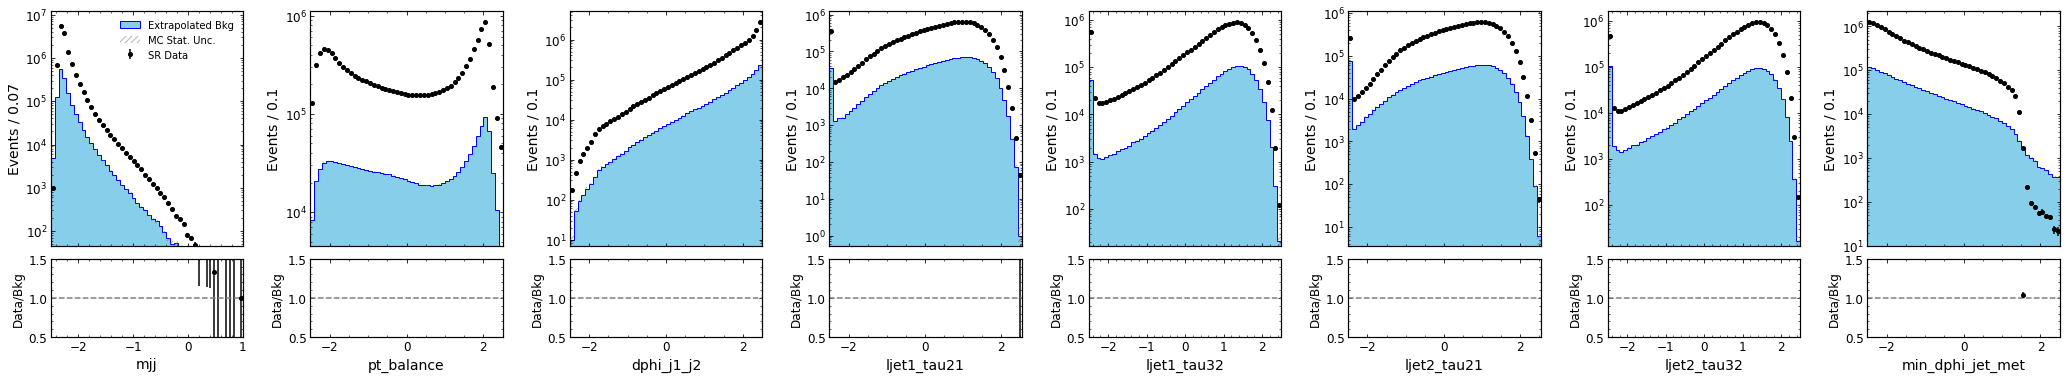

Combined 1-row plot saved to: CWoLa_CR/publication_plots/All_Features_1Row.pdf


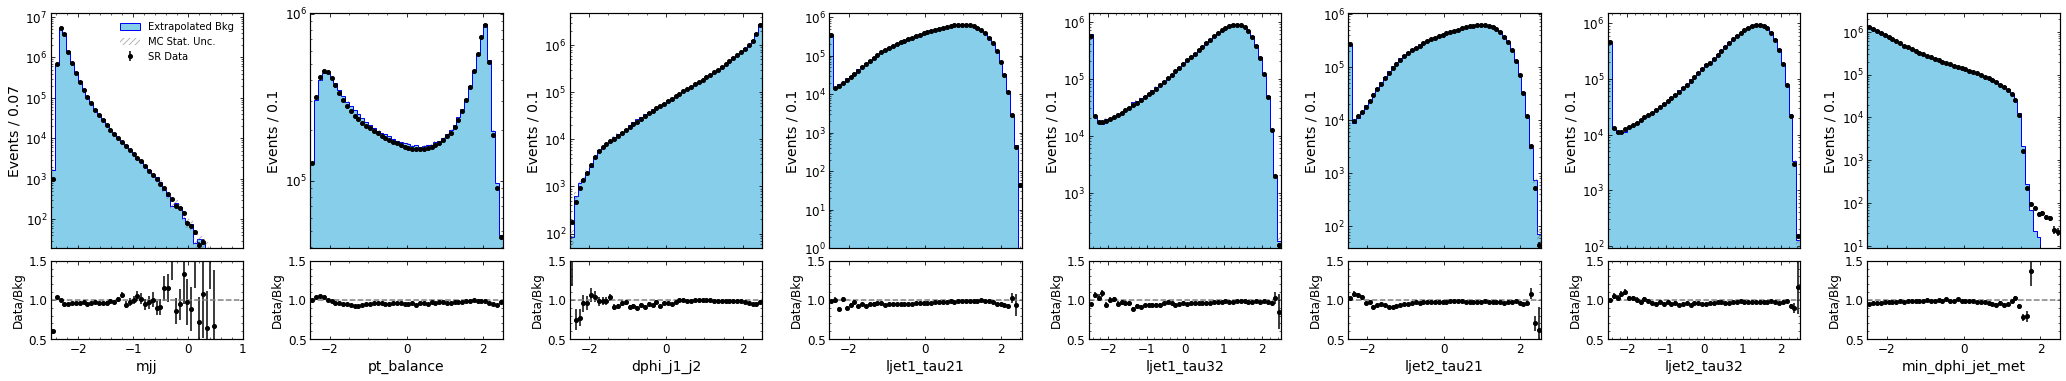

Combined 1-row plot saved to: CWoLa_CR/publication_plots/All_Features_1Row.pdf


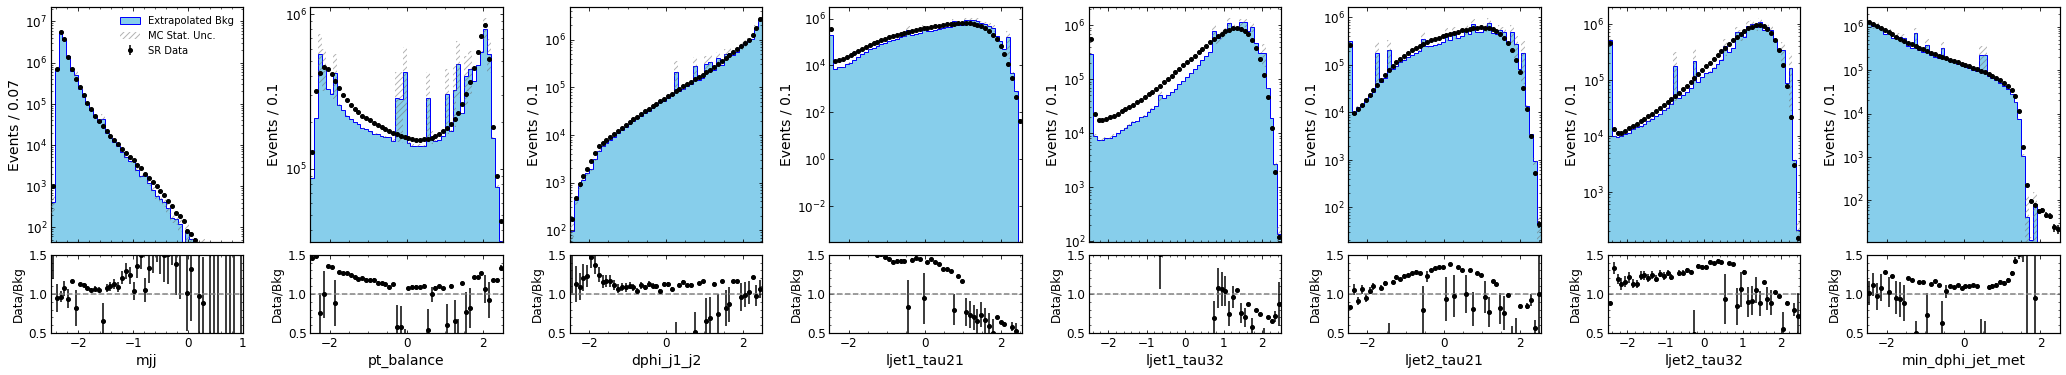

Combined 1-row plot saved to: CWoLa_CR/publication_plots/All_Features_1Row.pdf


In [9]:
print("CWoLA Evaluation on Reweight Samples")

print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")
print("Shapes of feature arrays:", data_events_cr.shape, mc_events_cr.shape)
data_cr_test = data_events_cr.values
mc_cr_test = mc_events_cr.values

model = "reweight"
model_path_full = f"{model_path}/{model}.pt"
print("Loading model from:", model_path_full)

NN_reweight = torch.load(model_path_full, weights_only=False)
NN_reweight.to(device)

print(NN_reweight.n_inputs)

print("Generating samples")
w_cr = NN_reweight.evaluation(mc_cr_test)
w_cr = (w_cr/(1-w_cr)).flatten()  

set_1 = mc_events_cr[features].values
w_1 = w_cr*(len(data_events_cr)/len(mc_events_cr))
# w_1 = np.ones(set_1.shape[0])
set_2 = data_events_cr[features].values
# set_2 = resample(set_2, replace=False, n_samples=len(set_1))
w_1_1 = np.ones(set_1.shape[0])

w_1_2 = weights/np.sum(weights)*(len(set_2))
print(set_1.shape, w_1.shape, set_2.shape)
plot(set_1, set_2, w_1_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")
plot(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")
plot(set_1, set_2, w_1_2, feature_names=features, save_dir=f"{eval_dir}/publication_plots")

# run_eval(set_1, set_2, w_1 = w_1, code=f"reweight_cr", save_dir=eval_dir, classifier_params=params, device=device)

CWoLA Evaluation on Reweight Samples
CR has 13198578 data events, 1426844 MC events.
Shapes of feature arrays: (13198578, 10) (1426844, 10)
Loading model from: /home/aegis/Titan1/NRAD/data/Models/reweight.pt
10
Generating samples
(1426844, 8) (1426844,) (13198578, 8)


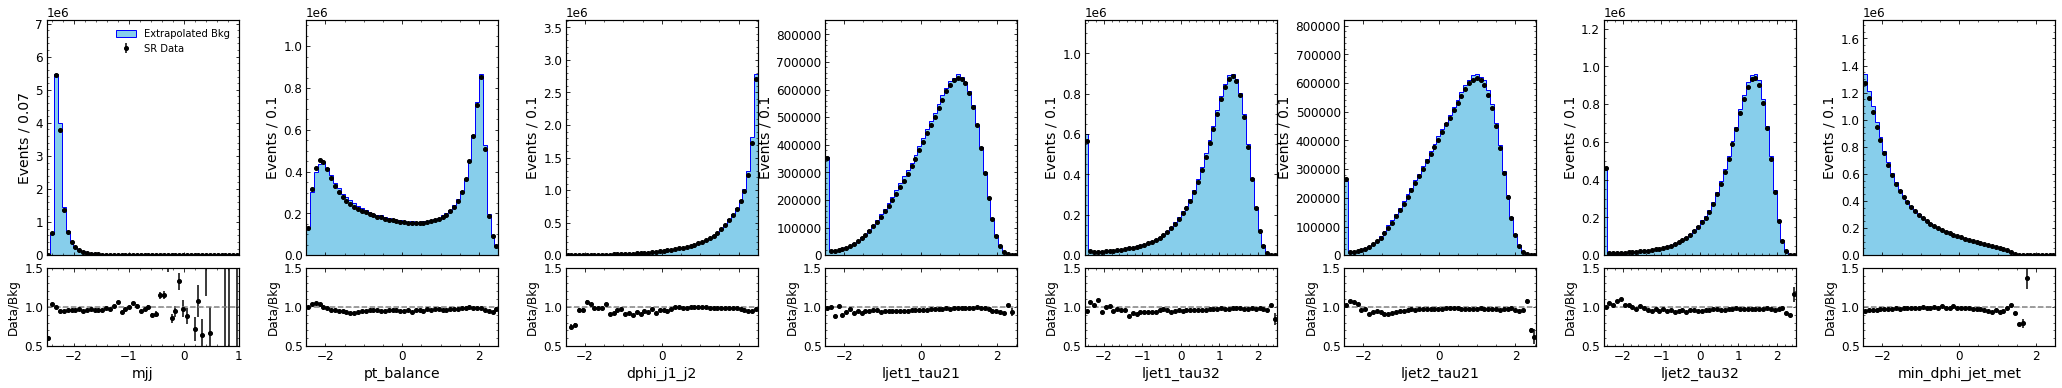


Working on reweight_cr...
      X_train, y_train, w_train: (14522920, 8) (14522920, 1) (14522920, 1)
      X_test, y_test: (102502, 8) (102502, 1)
Classifier run 1 of 20.
Using device: cpu


 26%|==>       | 13/50 [42:53<2:02:03, 197.94s/it]


   AUC: 0.5039123957455719
Classifier run 2 of 20.
Using device: cpu


 22%|==        | 11/50 [38:24<2:16:11, 209.53s/it]


   AUC: 0.5000254222293801
Classifier run 3 of 20.
Using device: cpu


...

   AUC: 0.5019321359801436
Classifier run 19 of 20.
Using device: cpu


 24%|==        | 12/50 [30:20<1:36:06, 151.75s/it]


   AUC: 0.5041448279888978
Classifier run 20 of 20.
Using device: cpu


 16%|=>        | 8/50 [18:02<1:34:42, 135.30s/it]


   AUC: 0.5040667258798586

Median AUC, 16th percentile, 84th percentile:
0.5035880858660419 [np.float64(0.5019325510261199), np.float64(0.5055444187860539)]
Done.



In [ ]:
# print("CWoLA Evaluation on Reweight Samples")

# print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")
# print("Shapes of feature arrays:", data_events_cr.shape, mc_events_cr.shape)
# data_cr_test = data_events_cr.values
# mc_cr_test = mc_events_cr.values

# model = "reweight"
# model_path_full = f"{model_path}/{model}.pt"
# print("Loading model from:", model_path_full)

# NN_reweight = torch.load(model_path_full, weights_only=False)
# NN_reweight.to(device)

# print(NN_reweight.n_inputs)

# print("Generating samples")
# w_cr = NN_reweight.evaluation(mc_cr_test)
# w_cr = (w_cr/(1-w_cr)).flatten()  

# set_1 = mc_events_cr[features].values
# w_1 = w_cr*(len(data_events_cr)/len(mc_events_cr))
# # w_1 = np.ones(set_1.shape[0])
# set_2 = data_events_cr[features].values
# # set_2 = resample(set_2, replace=False, n_samples=len(set_1))

# print(set_1.shape, w_1.shape, set_2.shape)
# plot(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")

# run_eval(set_1, set_2, w_1 = w_1, code=f"reweight_cr", save_dir=eval_dir, classifier_params=params, device=device)

In [ ]:
# import torch, numpy as np, gc

# def safe_sample(maf, cond, batch_size=1000, num_samples=1):
#     preds = []
#     for j in range(0, len(cond), batch_size):
#         cond_batch = cond[j:j+batch_size]
#         with torch.no_grad():
#             preds.append(maf.sample(num_samples, cond_batch))
#         # Free memory after each batch
#         torch.cuda.empty_cache()
#         gc.collect()
#     return np.concatenate(preds, axis=0)

In [ ]:
# print("CWoLA Evaluation on Generate Samples")

# print("CR has", len(data_events_cr), "data events,", len(mc_events_cr), "MC events.")

# data_cr_test = data_events_cr[context_var].values
# mc_cr_test = mc_events_cr[context_var].values

# model = "context_weight"
# model_path_full = f"{model_path}/{model}.pt"
# print("Model path:", model_path_full)

# NN_cw = torch.load(model_path_full, weights_only=False)
# NN_cw.to(device)
# print(NN_cw.n_inputs)

# print("Generating context weights for CR...")
# print("Shapes of context variable arrays:", data_cr_test.shape, mc_cr_test.shape)
# w_cr = NN_cw.evaluation(mc_cr_test)
# w_cr = (w_cr / (1-w_cr)).flatten()
# # w_cr = w_cr
# model_gen = "generate"
# model_gen_path_full = f"{model_path}/{model_gen}.pt"
# print("Loading model from:", model_gen_path_full)

# MAF = torch.load(model_gen_path_full, weights_only=False)
# MAF.to(device)

# print("Generating samples")
# print(w_cr.shape)
# weighted_context = mc_cr_test*w_cr[:,np.newaxis]
# # pred_bkg_CR = MAF.sample(1, data_events_cr[context_var].values)
# pred_bkg_CR = safe_sample(MAF, data_events_cr[context_var].values, batch_size=1000000)
# set_1 = pred_bkg_CR
# lower_bound = -3
# upper_bound = 3
# valid_events_mask = np.all((set_1 >= lower_bound) & (set_1 <= upper_bound), axis=1)
# set_1 = set_1[valid_events_mask]
# set_2 = data_events_cr[features].values
# w_1 = np.ones(set_1.shape[0])
# plot(set_1, set_2, w_1, feature_names=features, save_dir=f"{eval_dir}/publication_plots")

# # run_eval(set_1, set_2, code=f"generate_cr", save_dir=eval_dir, classifier_params=params, device=device)


CWoLA Evaluation on Generate Samples


NameError: name 'data_events_cr' is not defined

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_all_comparisons_to_data(
    data_samples,
    unweighted_samples,
    reweight_samples, reweight_weights,
    generate_samples,
    mc_weighted_samples, mc_weights,
    feature_names,
    log_features=None,
    save_dir=None,
    bins=50,
    val_range=(-3.0, 3.0),
    ratio_ylim=(0.5, 1.5)
):
    """
    Plots Data and various MC variants with comprehensive statistical uncertainties.
    Includes beautiful LaTeX formatting for axes labels and titles.
    """
    if log_features is None:
        log_features = []
    if save_dir and not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    w_unweighted = np.ones(unweighted_samples.shape[0])
    gen_weight_val = len(data_samples) / generate_samples.shape[0]
    w_generate = np.ones(generate_samples.shape[0]) * gen_weight_val

    # Standard High Energy Physics color palette
    colors = {
        'unw': 'tab:blue',
        'rew': 'tab:orange',
        'gen': 'tab:green',
        'mc':  'tab:red',
        'data': 'black'
    }

    # LaTeX mappings for your specific features
    feature_labels = {
        'mjj': r"$m_{jj}$",
        'pt_balance': r"$p_{\text{T}}^{\text{bal}}$",
        'dphi_j1_j2': r"$|\phi_{max} - \phi_{min}|$",
        'ljet1_tau21': r"Jet 1 $\tau_{21}$",
        'ljet1_tau32': r"Jet 1 $\tau_{32}$",
        'ljet2_tau21': r"Jet 2 $\tau_{21}$",
        'ljet2_tau32': r"Jet 2 $\tau_{32}$",
        'min_dphi_jet_met': r"$\min(\Delta\phi(E_{\text{T}}^{\text{miss}}, \text{Jet}))$"
    }

    for i, feature in enumerate(feature_names):
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1, figsize=(10, 10), 
            gridspec_kw={'height_ratios': [3, 1]}, sharex=True
        )
        plt.subplots_adjust(hspace=0.05) 
        
        # Get the pretty label, fallback to raw feature name if not found
        display_label = feature_labels.get(feature, feature)
        
        # --- 1. CALCULATE HISTOGRAMS & ERRORS ---
        counts_data, bin_edges = np.histogram(data_samples[:, i], bins=bins, range=val_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        err_data = np.sqrt(counts_data) 
        
        counts_unw, _ = np.histogram(unweighted_samples[:, i], bins=bin_edges)
        err_unw = np.sqrt(counts_unw) 
        
        counts_rew, _ = np.histogram(reweight_samples[:, i], bins=bin_edges, weights=reweight_weights)
        var_rew, _ = np.histogram(reweight_samples[:, i], bins=bin_edges, weights=reweight_weights**2)
        err_rew = np.sqrt(var_rew)
        
        counts_gen, _ = np.histogram(generate_samples[:, i], bins=bin_edges, weights=w_generate)
        var_gen, _ = np.histogram(generate_samples[:, i], bins=bin_edges, weights=w_generate**2)
        err_gen = np.sqrt(var_gen)
        
        counts_mc, _ = np.histogram(mc_weighted_samples[:, i], bins=bin_edges, weights=mc_weights)
        var_mc, _ = np.histogram(mc_weighted_samples[:, i], bins=bin_edges, weights=mc_weights**2)
        err_mc = np.sqrt(var_mc)

        # --- 2. MAIN PANEL (TOP) ---
        def plot_mc(ax, counts, errs, color, label):
            ax.hist(bin_centers, bins=bin_edges, weights=counts, histtype='step', 
                    linewidth=2, color=color, label=label, alpha=0.9)
            ax.errorbar(bin_centers, counts, yerr=errs, fmt='none', ecolor=color, alpha=0.5, zorder=3)

        plot_mc(ax1, counts_unw, err_unw, colors['unw'], 'Unweighted MC')
        plot_mc(ax1, counts_rew, err_rew, colors['rew'], 'Reweighted')
        plot_mc(ax1, counts_gen, err_gen, colors['gen'], 'Generated (MAF)')
        plot_mc(ax1, counts_mc, err_mc, colors['mc'], 'MC Weighted')
        
        ax1.errorbar(bin_centers, counts_data, yerr=err_data, fmt='ko', label='Data', zorder=5)
        
        ax1.set_ylabel("Events / Bin", fontsize=12)
        # Use the pretty label in the title
        # ax1.set_title(f"Distribution Comparison for {display_label}", fontsize=14, fontweight='bold')
        ax1.legend(loc='best', frameon=False, fontsize=11)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        max_y = max(np.max(counts_data), np.max(counts_gen), np.max(counts_mc), np.max(counts_rew))
        if feature in log_features:
            ax1.set_yscale('log')
            ax1.set_ylim(0.1, max_y * 50) 
        else:
            ax1.set_ylim(0, max_y * 1.3)
            
        # --- 3. RATIO PANEL (BOTTOM) ---
        valid_mask = counts_data > 0
        safe_data = np.where(valid_mask, counts_data, 1e-10)
        
        rel_err_data = err_data / safe_data
        rel_err_data[~valid_mask] = 0 
        
        ax2.fill_between(
            bin_edges, 
            np.append(1 - rel_err_data, 1 - rel_err_data[-1]), 
            np.append(1 + rel_err_data, 1 + rel_err_data[-1]), 
            step='post', color='gray', alpha=0.3, label='Data Stat. Unc.', zorder=1
        )
        ax2.axhline(1.0, color='black', linestyle='--', zorder=2)
        
        def plot_ratio(ax, counts, errs, color):
            ratio = counts / safe_data
            ratio_err = errs / safe_data 
            
            ratio_plot = np.where(valid_mask, ratio, np.nan)
            
            ax.step(bin_edges, np.append(ratio_plot, ratio_plot[-1]), where='post', 
                    linewidth=1.5, color=color, alpha=0.8)
            
            ax.errorbar(bin_centers[valid_mask], ratio_plot[valid_mask], 
                        yerr=ratio_err[valid_mask], fmt='none', ecolor=color, alpha=0.5)

        plot_ratio(ax2, counts_unw, err_unw, colors['unw'])
        plot_ratio(ax2, counts_rew, err_rew, colors['rew'])
        plot_ratio(ax2, counts_gen, err_gen, colors['gen'])
        plot_ratio(ax2, counts_mc, err_mc, colors['mc'])
        
        # Use the pretty label on the x-axis
        ax2.set_xlabel(display_label, fontsize=12)
        ax2.set_ylabel("MC / Data", fontsize=12)
        ax2.set_ylim(ratio_ylim) 
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"{feature}_combined.png"), bbox_inches='tight', dpi=300)
            plt.savefig(os.path.join(save_dir, f"{feature}_combined.pdf"), bbox_inches='tight')
        
        plt.show()
        plt.close()

(1426844, 8)
(13198578, 8)
Loading model from: /home/aegis/Titan1/NRAD/data/Models/reweight.pt
10
Generating samples


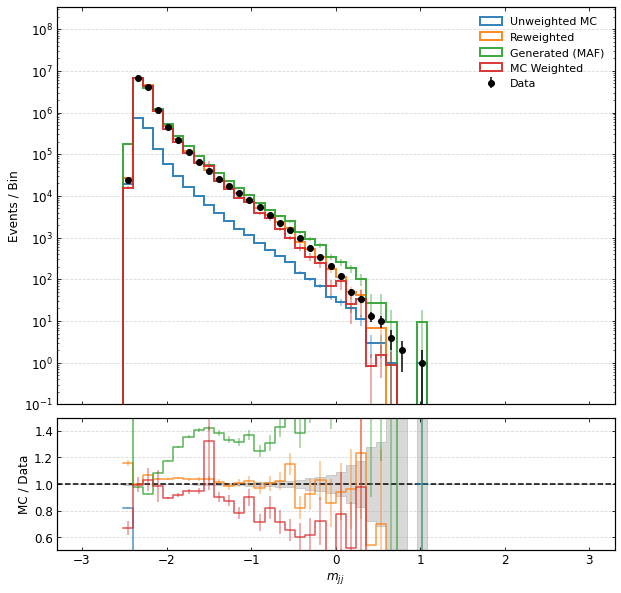

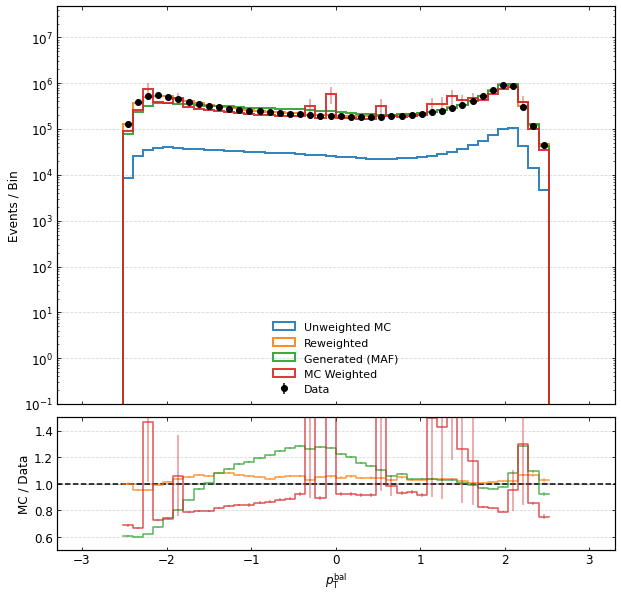

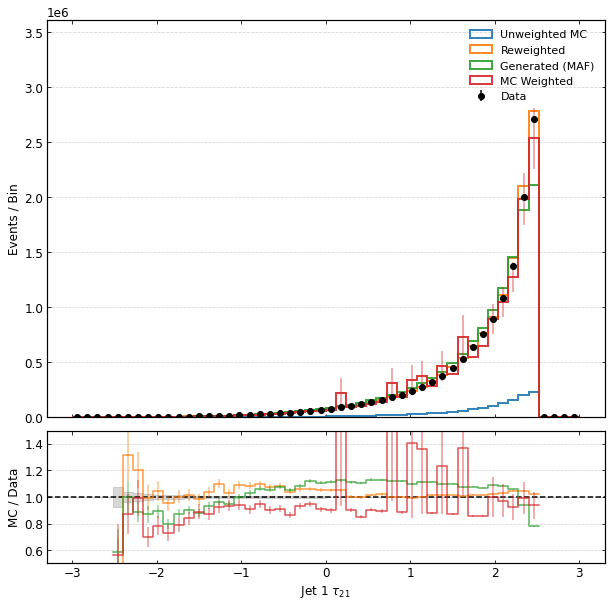

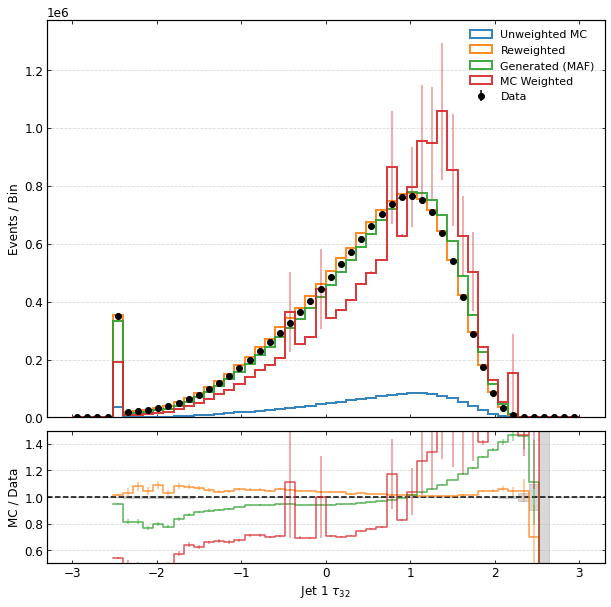

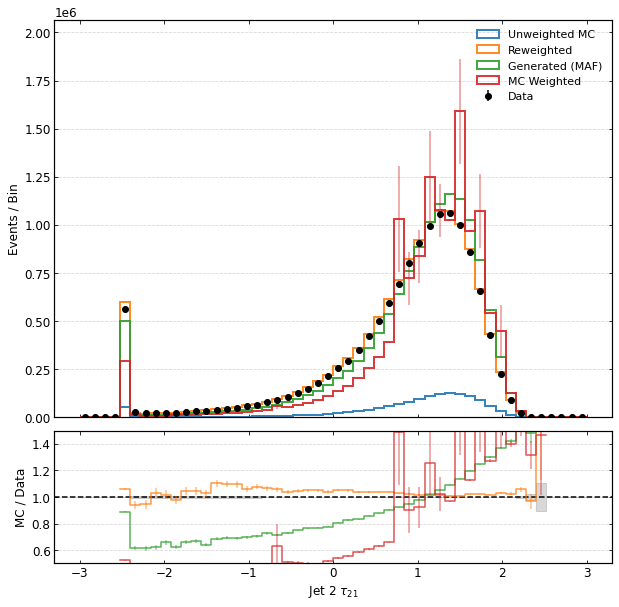

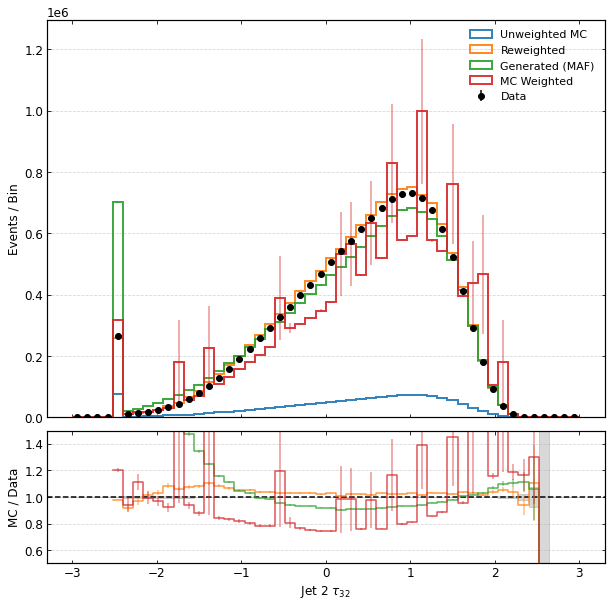

In [13]:
features_list = ['mjj', 'pt_balance', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
features_to_log = ['mjj', 'pt_balance', 'dphi_j1_j2', 'min_dphi_jet_met']


unweighted = mc_events_cr[features].values

print(unweighted.shape)
print(set_2.shape)

model = "reweight"
model_path_full = f"{model_path}/{model}.pt"
print("Loading model from:", model_path_full)

NN_reweight = torch.load(model_path_full, weights_only=False)
NN_reweight.to(device)

print(NN_reweight.n_inputs)

print("Generating samples")
w_cr = NN_reweight.evaluation(mc_events_cr.values)
w_cr = (w_cr/(1-w_cr)).flatten()  

w_1 = w_cr*(len(data_events_cr)/len(mc_events_cr.values))
w_1_2 = weights/np.sum(weights)*(len(set_2))

plot_all_comparisons_to_data(data_samples = set_2, unweighted_samples=unweighted, reweight_samples=unweighted, reweight_weights=w_1, generate_samples=set_1, mc_weighted_samples=unweighted, mc_weights=w_1_2,
                                feature_names=features_list,
    log_features=features_to_log, # Applies log scale only to these
    # save_dir=f"{eval_dir}/publication_plots",
    bins=50,
    val_range=(-3, 3))

In [9]:
run_eval(set_1, set_2, w_1=w_1, code=f"generate_cr", save_dir=eval_dir, classifier_params=params, device=device)


Working on generate_cr...
      X_train, y_train, w_train: (26362042, 8) (26362042, 1) (26362042, 1)
      X_test, y_test: (20012, 8) (20012, 1)
Classifier run 1 of 20.
Using device: cpu


 34%|===       | 17/50 [1:06:30<2:09:06, 234.75s/it]


   AUC: 0.6430954754294846
Classifier run 2 of 20.
Using device: cpu


 52%|=====     | 26/50 [1:43:05<1:35:09, 237.91s/it]


   AUC: 0.6445191520175789
Classifier run 3 of 20.
Using device: cpu


...

   AUC: 0.6498993108270076
Classifier run 19 of 20.
Using device: cpu


 36%|===>      | 18/50 [38:57<1:09:15, 129.87s/it]


   AUC: 0.6408582351178584
Classifier run 20 of 20.
Using device: cpu


 32%|===       | 16/50 [34:34<1:13:27, 129.64s/it]


   AUC: 0.6415589143028366

Median AUC, 16th percentile, 84th percentile:
0.6426556956652018 [np.float64(0.6369101316420296), np.float64(0.6465090729125049)]
Done.

